<a href="https://colab.research.google.com/github/DOHA-BASEM3/Activity-3--DBSCAN-and-PCA/blob/main/DBSCAN_and_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Course: Machine Learning II
# DBSCAN + PCA ASSIGNMENT
# Team Members : Ghena , Oraib , Doha
# Data set :Iris Species

# **Import libraries**

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# **Load Dataset**

In [4]:
# Load dataset
url = "https://raw.githubusercontent.com/DOHA-BASEM3/Activity-3--DBSCAN-and-PCA/refs/heads/main/archive/Iris.csv"
df = pd.read_csv(url)

In [27]:
# ---------------------------
# Data Exploration (EDA)
# ---------------------------

print("First 5 Rows:")
print(df.head())

print("\n" + "="*50)
print("Dataset Information:")
df.info()

print("\n" + "="*50)

print("Statistical Summary:")
print(df.describe())


print("\n" + "="*50)

print("Missing Values:")
print(df.isnull().sum())  # no missing values found

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory

# **Data Preprocessing**

In [28]:
# Check duplicates

print("Duplicate rows:", df.duplicated().sum())  # no duplicate rows found

# Drop unnecessary column
df_cleaned = df.drop(columns=['Id', 'Species'])
true_labels = df['Species']

# Dataset has no missing values
# No imputation needed

# Apply standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)

print(f"Shape: {X_scaled.shape} Mean: {X_scaled.mean().round(2)}  Std: {X_scaled.std().round(2)}")
print("Preprocessing done successfully!")

Duplicate rows: 0
Shape: (150, 4) Mean: -0.0  Std: 1.0
Preprocessing done successfully!


# **PCA Implementation**

In [29]:
# - Apply PCA (2 components)
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

In [30]:
# - Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.72770452 0.23030523]
Total variance retained: 0.9580097536148199


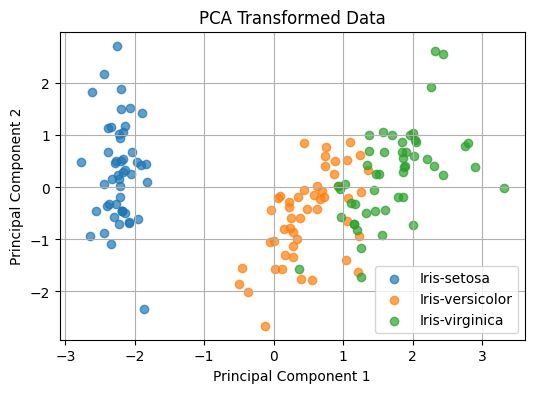

In [31]:
#  PCA scatter plot

plt.figure(figsize=(6,4))

for species in true_labels.unique():
    mask = true_labels == species
    plt.scatter(X_pca[mask,0], X_pca[mask,1], label=species, alpha=0.7)

plt.legend()
plt.title("PCA Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# **DBSCAN Clustering**

**DBSCAN on Original Data**

Tune eps on Original Data

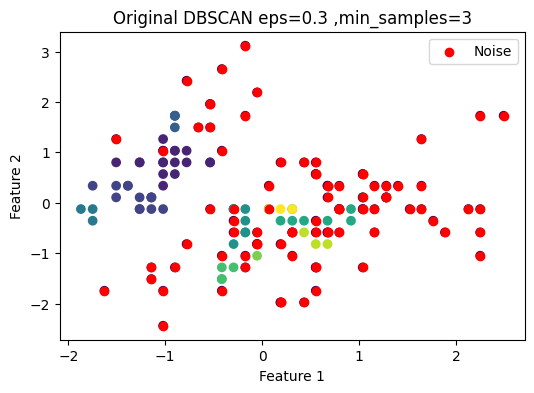

In [32]:
# Trial 1
# DBSCAN eps=0.3 / min_samples=3
dbscan = DBSCAN(eps=0.3, min_samples=3)
labels_original  = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1] , c=labels_original )
plt.scatter(X_scaled[labels_original  == -1, 0], X_scaled[labels_original  == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Original DBSCAN eps=0.3 ,min_samples=3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

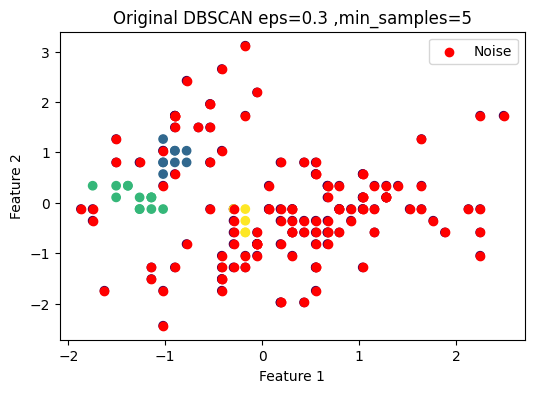

In [33]:

# Trial 2
# DBSCAN eps=0.3  / min_samples=5
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_original = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1] , c=labels_original )
plt.scatter(X_scaled[labels_original  == -1, 0], X_scaled[labels_original == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Original DBSCAN eps=0.3 ,min_samples=5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

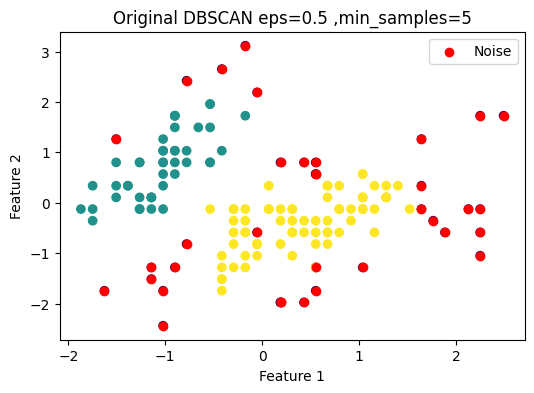

In [34]:
# Trial 3
# DBSCAN eps=0.5 /min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_original  = dbscan.fit_predict(X_scaled)
colors = {0: 'teal', 1: 'gold', -1: 'red'}

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_original ),
plt.scatter(X_scaled[labels_original  == -1, 0], X_scaled[labels_original  == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Original DBSCAN eps=0.5 ,min_samples=5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

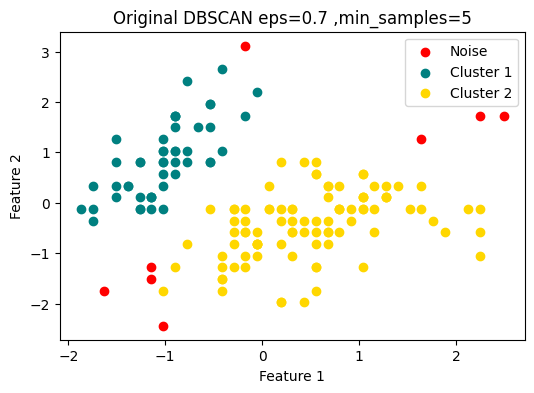

In [49]:

# Trial 4
# DBSCAN eps=0.7 / min_samples=5
dbscan_original = DBSCAN(eps=0.7, min_samples=5)
labels_original = dbscan_original.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
colors = {0: 'teal', 1: 'gold', -1: 'red'}
for label in sorted(set(labels_original)):
    mask = labels_original == label
    name = f'Cluster {label+1}' if label != -1 else 'Noise'
    plt.scatter(X_scaled[mask,0], X_scaled[mask,1], c=colors[label], label=name)
plt.legend()
plt.title("Original DBSCAN eps=0.7 ,min_samples=5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

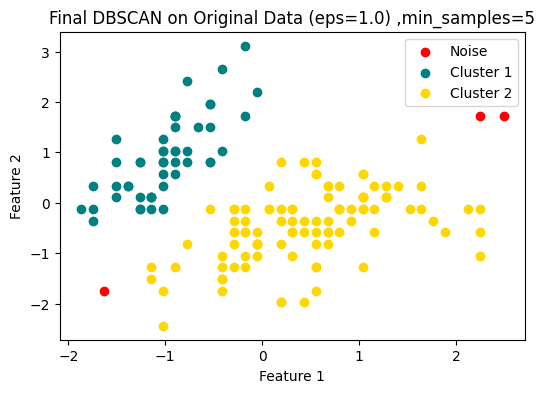

In [36]:
# # Final DBSCAN on Original Data
# DBSCAN eps=1.0
dbscan_original = DBSCAN(eps=1.0, min_samples=5)
labels_original = dbscan_original.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
colors = {0: 'teal', 1: 'gold', -1: 'red'}
for label in sorted(set(labels_original)):
    mask = labels_original == label
    name = f'Cluster {label+1}' if label != -1 else 'Noise'
    plt.scatter(X_scaled[mask,0], X_scaled[mask,1], c=colors[label], label=name)
plt.legend()
plt.title("Final DBSCAN on Original Data (eps=1.0) ,min_samples=5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**DBSCAN on PCA Data**

Tune eps and min_samples on PCA data


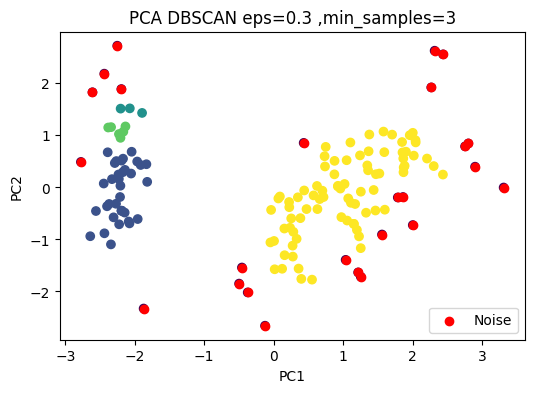

In [37]:
# Trial 1
# DBSCAN eps=0.3 & min_samples=3
dbscan = DBSCAN(eps=0.3, min_samples=3)
labels_pca  = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca )
plt.scatter(X_pca[labels_pca  == -1, 0], X_pca[labels_pca  == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("PCA DBSCAN eps=0.3 ,min_samples=3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

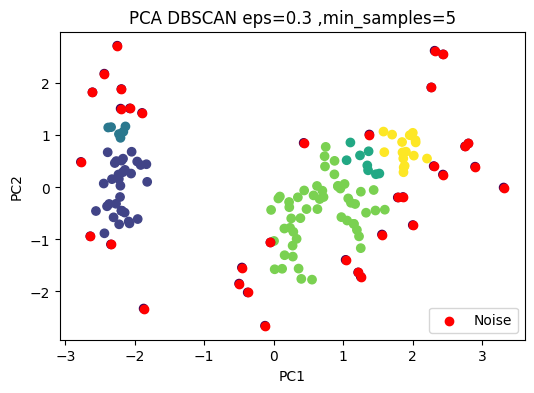

In [38]:
# Trial 2
# DBSCAN eps=0.3 & min_samples=5
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_pca  = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca )
plt.scatter(X_pca[labels_pca  == -1, 0], X_pca[labels_pca  == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("PCA DBSCAN eps=0.3 ,min_samples=5")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

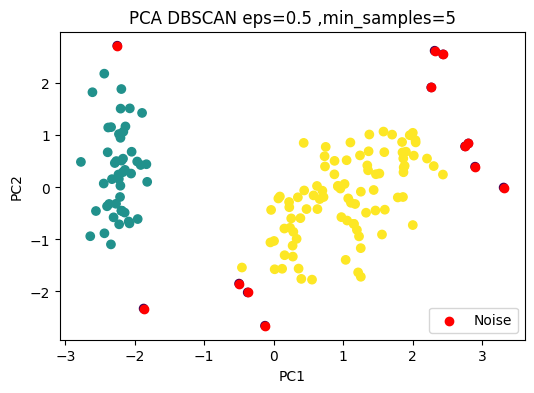

In [39]:
# Trial 3
# DBSCAN eps=0.5 & min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_pca  = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca )
plt.scatter(X_pca[labels_pca  == -1, 0], X_pca[labels_pca == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("PCA DBSCAN eps=0.5 ,min_samples=5")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

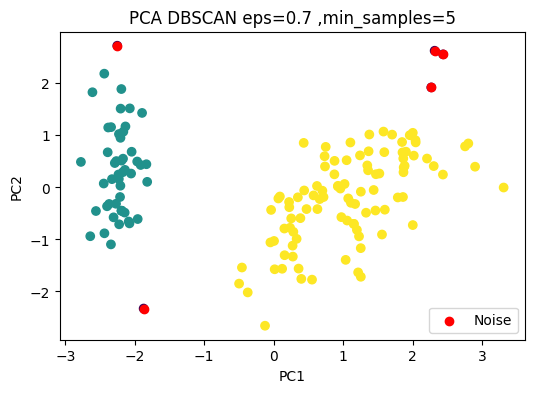

In [40]:
# Trial 4
# DBSCAN eps=0.7 & min_samples=5
dbscan_pca = DBSCAN(eps=0.7, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.scatter(X_pca[labels_pca == -1, 0], X_pca[labels_pca == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("PCA DBSCAN eps=0.7 ,min_samples=5")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

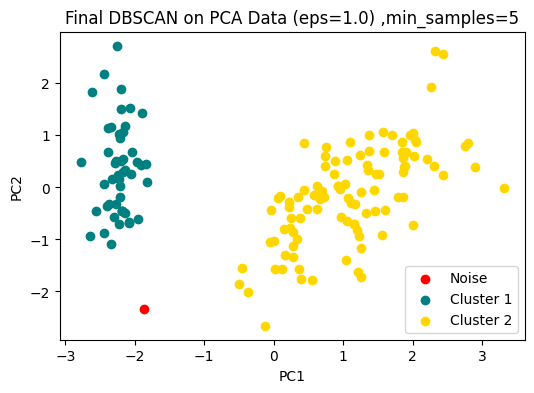

In [41]:
# Final DBSCAN on PCA Data
# DBSCAN eps=1.0 & min_samples=5
dbscan_pca = DBSCAN(eps=1.0, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

plt.figure(figsize=(6,4))
colors = {0: 'teal', 1: 'gold', -1: 'red'}
for label in sorted(set(labels_pca)):
    mask = labels_pca == label
    name = f'Cluster {label+1}' if label != -1 else 'Noise'
    plt.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[label], label=name)
plt.legend()
plt.title("Final DBSCAN on PCA Data (eps=1.0) ,min_samples=5")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

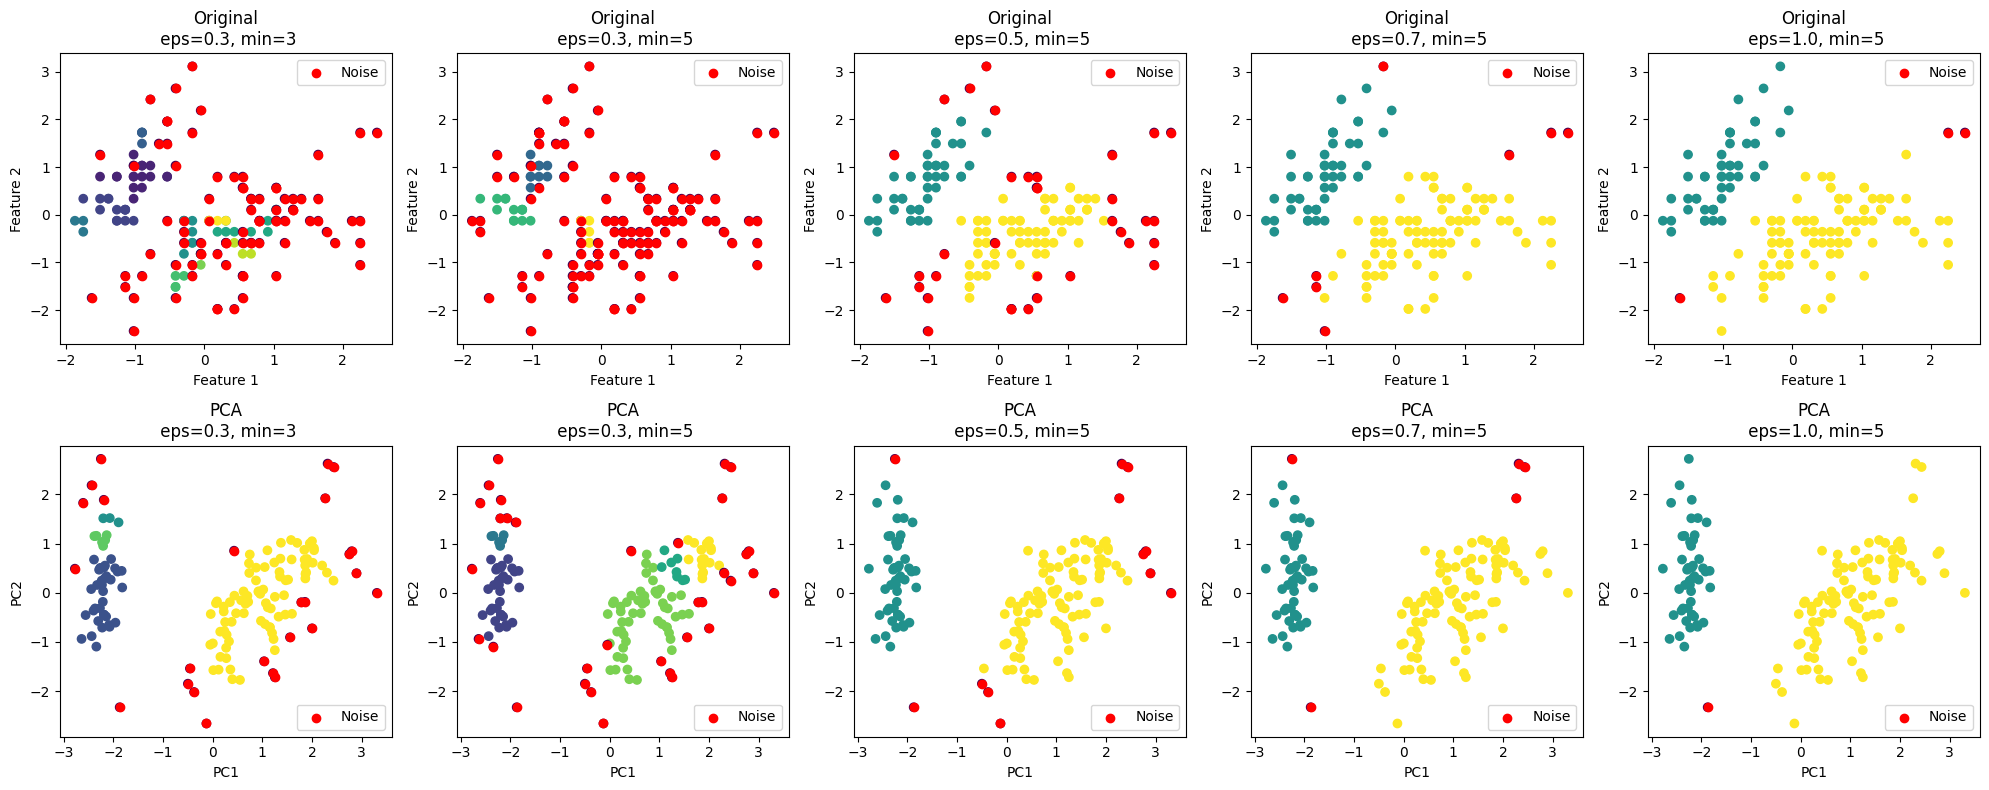

In [42]:
trials = [
    (0.3, 3),
    (0.3, 5),
    (0.5, 5),
    (0.7, 5),
    (1.0, 5)
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (eps, min_samples) in enumerate(trials):

    # ORIGINAL
    dbscan_original = DBSCAN(eps=eps, min_samples=min_samples)
    labels_original = dbscan_original.fit_predict(X_scaled)

    axes[0, i].scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels_original,
        cmap='viridis'
    )

    noise_original = labels_original == -1
    axes[0, i].scatter(
        X_scaled[noise_original, 0],
        X_scaled[noise_original, 1],
        c='red',
        label='Noise'
    )

    axes[0, i].set_title(f"Original\n eps={eps}, min={min_samples}")
    axes[0, i].set_xlabel("Feature 1")
    axes[0, i].set_ylabel("Feature 2")
    axes[0, i].legend()


    # PCA
    dbscan_pca = DBSCAN(eps=eps, min_samples=min_samples)
    labels_pca = dbscan_pca.fit_predict(X_pca)

    axes[1, i].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels_pca,
        cmap='viridis'
    )

    noise_pca = labels_pca == -1
    axes[1, i].scatter(
        X_pca[noise_pca, 0],
        X_pca[noise_pca, 1],
        c='red',
        label='Noise'
    )

    axes[1, i].set_title(f"PCA\n eps={eps}, min={min_samples}")
    axes[1, i].set_xlabel("PC1")
    axes[1, i].set_ylabel("PC2")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

# **Analysis**

=== DBSCAN Results Comparison ===
Original Data Labels: {np.int64(0), np.int64(1), np.int64(-1)}
PCA Data Labels:      {np.int64(0), np.int64(1), np.int64(-1)}


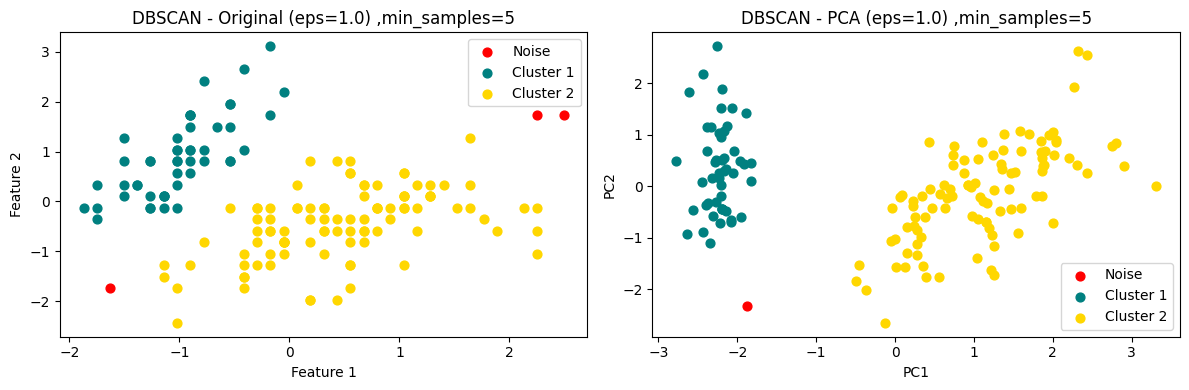

In [43]:
# - Compare results
print("=== DBSCAN Results Comparison ===")
print(f"Original Data Labels: {set(labels_original)}")
print(f"PCA Data Labels:      {set(labels_pca)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = {0: 'teal', 1: 'gold', -1: 'red'}

# Original
for label in sorted(set(labels_original)):
    mask = labels_original == label
    name = f'Cluster {label+1}' if label != -1 else 'Noise'
    ax1.scatter(X_scaled[mask,0], X_scaled[mask,1],
                c=colors[label], label=name, s=40)
ax1.set_title("DBSCAN - Original (eps=1.0) ,min_samples=5")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()

# PCA
for label in sorted(set(labels_pca)):
    mask = labels_pca == label
    name = f'Cluster {label+1}' if label != -1 else 'Noise'
    ax2.scatter(X_pca[mask,0], X_pca[mask,1],
                c=colors[label], label=name, s=40)
ax2.set_title("DBSCAN - PCA (eps=1.0) ,min_samples=5")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend()

plt.tight_layout()
plt.show()

In [44]:
#  Count clusters
n_clusters_orig = len(set(labels_original)) - (1 if -1 in labels_original else 0)
n_clusters_pca  = len(set(labels_pca))      - (1 if -1 in labels_pca else 0)

print(f"Original → Clusters: {n_clusters_orig}")
print(f"PCA      → Clusters: {n_clusters_pca}")


Original → Clusters: 2
PCA      → Clusters: 2


In [45]:
#  Count noise points
n_noise_orig = list(labels_original).count(-1)
n_noise_pca  = list(labels_pca).count(-1)

print(f"Original → Noise points: {n_noise_orig}")
print(f"PCA      → Noise points: {n_noise_pca}")


Original → Noise points: 3
PCA      → Noise points: 1


In [46]:
tuning_results = pd.DataFrame({
    "Trial":       ["Trial 1", "Trial 2", "Trial 3", "Trial 4", "Final"],
    "eps":         [0.3, 0.3, 0.5, 0.7,1.0],
    "min_samples": [3, 5, 5, 5, 5],
    "Original Clusters": [
        len(set(DBSCAN(eps=0.3, min_samples=3).fit_predict(X_scaled))) - 1,
        len(set(DBSCAN(eps=0.3, min_samples=5).fit_predict(X_scaled))) - 1,
        len(set(DBSCAN(eps=0.5, min_samples=5).fit_predict(X_scaled))) - 1,
        len(set(DBSCAN(eps=0.7, min_samples=5).fit_predict(X_scaled))) - 1,
        n_clusters_orig
    ],
    "Original Noise": [
        list(DBSCAN(eps=0.3, min_samples=3).fit_predict(X_scaled)).count(-1),
        list(DBSCAN(eps=0.3, min_samples=5).fit_predict(X_scaled)).count(-1),
        list(DBSCAN(eps=0.5, min_samples=5).fit_predict(X_scaled)).count(-1),
        list(DBSCAN(eps=0.7, min_samples=5).fit_predict(X_scaled)).count(-1),
        n_noise_orig
    ],
    "PCA Clusters": [
        len(set(DBSCAN(eps=0.3, min_samples=3).fit_predict(X_pca))) - 1,
        len(set(DBSCAN(eps=0.3, min_samples=5).fit_predict(X_pca))) - 1,
        len(set(DBSCAN(eps=0.5, min_samples=5).fit_predict(X_pca))) - 1,
        len(set(DBSCAN(eps=0.7, min_samples=5).fit_predict(X_pca))) - 1,
        n_clusters_pca
    ],
    "PCA Noise": [
        list(DBSCAN(eps=0.3, min_samples=3).fit_predict(X_pca)).count(-1),
        list(DBSCAN(eps=0.3, min_samples=5).fit_predict(X_pca)).count(-1),
        list(DBSCAN(eps=0.5, min_samples=5).fit_predict(X_pca)).count(-1),
        list(DBSCAN(eps=0.7, min_samples=5).fit_predict(X_pca)).count(-1),
        n_noise_pca
    ]
})

tuning_results

,Trial,eps,min_samples,Original Clusters,Original Noise,PCA Clusters,PCA Noise
0,Trial 1,0.3,3,10,84,4,25
1,Trial 2,0.3,5,3,120,5,34
2,Trial 3,0.5,5,2,35,2,12
3,Trial 4,0.7,5,2,8,2,5
4,Final,1.0,5,2,3,2,1


In [47]:
print(f"Original Data  → Clusters: {n_clusters_orig}, Noise points: {n_noise_orig}")
print(f"PCA Data       → Clusters: {n_clusters_pca}, Noise points: {n_noise_pca}")
print(f"\nPCA reduced noise from {n_noise_orig} to {n_noise_pca} while keeping {n_clusters_pca} clusters.")

Original Data  → Clusters: 2, Noise points: 3
PCA Data       → Clusters: 2, Noise points: 1

PCA reduced noise from 3 to 1 while keeping 2 clusters.


In [48]:
print(f"""
Applying PCA reduced noise {n_noise_orig} to {n_noise_pca}  while preserving the same number of clusters (2),
indicating better cluster separation and data representation.

Increasing min_samples made the clustering stricter, significantly reducing the number of clusters
and increasing noise, as fewer points satisfied the density conditions required to form clusters.
""")


Applying PCA reduced noise 3 to 1  while preserving the same number of clusters (2),
indicating better cluster separation and data representation.

Increasing min_samples made the clustering stricter, significantly reducing the number of clusters
and increasing noise, as fewer points satisfied the density conditions required to form clusters.

